## read train1

In [1]:
import numpy as np
import pandas as pd
from sympy import limit
import wandb

api = wandb.Api(
    api_key="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",
    timeout=60
)

# 1. Get last 10 runs (sorted by creation time descending)
runs = api.runs(
    "eibl-usc/graph-clip",
    filters={
        # "display_name": {"$regex": "trained_on_.._eval_on_.._..?_shot_.+"},
        # "config.dataset": "ukr_rus_twitter",
        # "config.task_name": "neighbor_matching",
    },
    order="-created_at",
    per_page=10,
    # limit to 10:
    lazy=False
)

In [2]:
rows = []
for run in runs:
    attrs = getattr(run, "_attrs", {}) or {}
    params = ((attrs.get("config") or {}).get("params") or {})
    summary = attrs.get("summaryMetrics") or {}

    rows.append({
        "run_id": attrs.get("name"),
        "display_name": attrs.get("displayName"),
        "state": attrs.get("state"),
        "dataset": params.get("dataset"),
        "task_name": params.get("task_name"),
        "prefix": params.get("prefix"),
        "pretrained_model_run": params.get("pretrained_model_run"),
        "n_shots": params.get("n_shots"),
        "n_way": params.get("n_way"),
        "n_query": params.get("n_query"),
        "zero_shot": params.get("zero_shot"),
        "test_accuracy": summary.get("test_accuracy"),
        "train_accuracy": summary.get("train_accuracy"),
        "test_f1": summary.get("test_f1"),
        "test_roc_auc": summary.get("test_roc_auc"),
        "created_at": attrs.get("createdAt"),
        'steps': attrs['historyKeys']['keys'].get('_step', {}).get('typeCounts', [{}])[0].get('count', np.nan),
        'tags': attrs.get("tags", []),
    })
df = pd.DataFrame(rows)
df["train1_dataset"] = df["pretrained_model_run"].str.extract(r"train1_(ukr_rus_twitter|midterm|covid19_twitter)_")
df["train1_task"] = df["pretrained_model_run"].str.extract(r"train1_.+?_(nm|pl|lp)_")
df["eval1_task"] = df["task_name"].map({
    "neighbor_matching": "nm",
    "temporal_link_prediction": "lp",
    "classification": "pl",
})
df['created_at'] = pd.to_datetime(df['created_at'])
df["shot_label"] = df.apply(lambda r: 0 if bool(r.get("zero_shot", False)) else r["n_shots"], axis=1)
# df['is_eval'] = df['display_name'].str.contains(r"eval")
# plot_df = df[df["eval1_task"].isin(EVAL_TASKS) & df["train1_task"].eq("nm")].copy()
df['eval1_dataset'] = df['dataset']
df['trained_on_display_name'] = df.pretrained_model_run.str.split('/').str[1]
df['month/day'] = df['created_at'].dt.month.astype(str) + '/' + df['created_at'].dt.day.astype(str)
df = df.sort_values('created_at', ascending=False)
d = {
    'trained_on_n_way': 'n_way',
    'trained_on_n_query': 'n_query',
    'trained_on_n_shots': 'n_shots',
    'trained_on_steps': 'steps',
}
mask = df['trained_on_display_name'].isin(df['display_name'])
existing_trained_on_display_names = df.trained_on_display_name[mask]
dname2stats = df.set_index('display_name').loc[existing_trained_on_display_names][list(d.values())]
for col, stat in d.items():
    df[col] = df.trained_on_display_name.map(dname2stats[stat].to_dict())
df__ = df.copy()

df = df[df.state.ne('running')]
# allowed_shots = [0, 1, 2, 5, 10]
# df = df[df["n_shots"].isin(allowed_shots)]
unique_on = ['train1_dataset', 'train1_task', 'eval1_dataset', 'eval1_task', 'n_shots']#, 'n_query', 'n_way']
df = df.drop_duplicates(subset=unique_on, keep='first')
df_ = df.copy()

In [3]:
train1 = df_.copy()


train1_pretrained_models = [
    "state/train1_ukr_rus_twitter_nm_1p5m_13_04_2026_12_40_49/checkpoint/state_dict_40000.ckpt",
    "state/train1_midterm_nm_1p5m_13_04_2026_18_03_58/checkpoint/state_dict_40000.ckpt",
    "state/train1_covid19_twitter_nm_1p5m_13_04_2026_12_14_58/checkpoint/state_dict_40000.ckpt",
    "state/train1_ukr_rus_twitter_pl_1p5m_13_04_2026_11_30_52/checkpoint/state_dict_22000.ckpt",
    "state/train1_midterm_pl_1p5m_13_04_2026_17_14_38/checkpoint/state_dict_22000.ckpt",
    "state/train1_covid19_twitter_pl_1p5m_13_04_2026_11_43_04/checkpoint/state_dict_22000.ckpt",
    "state/train1_ukr_rus_twitter_lp_1p5m_13_04_2026_17_00_47/checkpoint/state_dict_28000.ckpt",
    "state/train1_midterm_lp_1p5m_13_04_2026_18_19_00/checkpoint/state_dict_28000.ckpt",
    "state/train1_covid19_twitter_lp_1p5m_13_04_2026_15_42_52/checkpoint/state_dict_28000.ckpt",
]

train1 = train1[train1.pretrained_model_run.isin(train1_pretrained_models)]
train1['train2_dataset'] = np.nan
train1['train2_task'] = np.nan
train1 = train1[train1.display_name.str.startswith('eval')]

#  election2020, covid_political, ukr_rus_suspended
train1_eval_datasets =["ukr_rus_twitter","midterm","covid19_twitter"]
train1 = train1[train1.eval1_dataset.isin(train1_eval_datasets)]
train1 = train1.rename(columns={'eval1_dataset': 'eval_dataset', 'eval1_task': 'eval_task'})

## read train2

In [79]:
path = "/Users/philipp/Downloads/train2_results_ext.csv"
train2 = pd.read_csv(path)

train2 = train2.rename(columns={
    "pretrain_dataset": "train1_dataset",
    "pretrain_task": "train1_task",
    "finetune_dataset": "train2_dataset",
    "finetune_task": "train2_task",})

train2['train1_task'] = train2['train1_task'].str.lower()
train2['train2_task'] = train2['train2_task'].str.lower()
train2['eval_task'] = train2['eval_task'].str.lower()

## plot comparison

In [80]:
train2['train1_dataset'] = train2['train1_dataset'].str.replace('ukr_rus', 'ukr_rus_twitter', regex=False)
train2['train2_dataset'] = train2['train2_dataset'].str.replace('ukr_rus', 'ukr_rus_twitter', regex=False)
train2['eval_dataset'] = train2['eval_dataset'].str.replace('ukr_rus', 'ukr_rus_twitter', regex=False)
train2['train1_dataset'] = train2['train1_dataset'].str.replace('midterm', 'midterm', regex=False)
train2['train2_dataset'] = train2['train2_dataset'].str.replace('midterm', 'midterm', regex=False)
train2['eval_dataset'] = train2['eval_dataset'].str.replace('midterm', 'midterm', regex=False)
train2['train1_dataset'] = train2['train1_dataset'].str.replace('covid', 'covid19_twitter', regex=False)
train2['train2_dataset'] = train2['train2_dataset'].str.replace('covid', 'covid19_twitter', regex=False)
train2['eval_dataset'] = train2['eval_dataset'].str.replace('covid', 'covid19_twitter', regex=False)


train1['seq_id'] = train1.train1_dataset + '+' + train1.train1_task + '|' + train1.eval_dataset + '+' + train1.eval_task
train2['seq_id'] = train2.train1_dataset + '+' + train2.train1_task + '>' + train2.train2_dataset + '+' + train2.train2_task + '|' + train2.eval_dataset + '+' + train2.eval_task
train1['train_id'] = train1.train1_dataset + '+' + train1.train1_task
train2['train_id'] = train2.train1_dataset + '+' + train2.train1_task + '>' + train2.train2_dataset + '+' + train2.train2_task
train1['eval_id'] = train1.eval_dataset + '+' + train1.eval_task
train2['eval_id'] = train2.eval_dataset + '+' + train2.eval_task

# df['baseline']
train1['train1_tuple'] = train1['train1_dataset'] + '+' + train1['train1_task']
train2['train1_tuple'] = train2['train1_dataset'] + '+' + train2['train1_task']
train2['train2_tuple'] = train2['train2_dataset'] + '+' + train2['train2_task']
train1['eval_tuple'] = train1['eval_dataset'] + '+' + train1['eval_task']
train2['eval_tuple'] = train2['eval_dataset'] + '+' + train2['eval_task']

In [81]:
train2['n_shots'] = train2.shots

In [82]:
# merge on eval_id
train1['exp_name'] = 'train1'
train2['exp_name'] = 'train2'
df = pd.concat([train1, train2], ignore_index=True)

v0_datasets = ['ukr_rus_twitter', 'midterm', 'covid19_twitter']
df = df[df.eval_dataset.isin(v0_datasets)]

In [83]:
df[['train_id', 'eval_id', 'n_shots', 'test_roc_auc']]

,train_id,eval_id,n_shots,test_roc_auc
0,midterm+pl,ukr_rus_twitter+pl,10.0,0.749280
1,midterm+pl,ukr_rus_twitter+lp,10.0,0.567073
2,midterm+pl,ukr_rus_twitter+nm,10.0,0.673774
3,midterm+pl,ukr_rus_twitter+pl,3.0,0.700935
4,midterm+pl,ukr_rus_twitter+lp,3.0,0.576442
...,...,...,...,...
454,ukr_rus_twitter+nm>covid19_twitter+nm,midterm+lp,5.0,0.924000
455,ukr_rus_twitter+nm>covid19_twitter+nm,midterm+lp,10.0,0.940000
456,ukr_rus_twitter+nm>covid19_twitter+nm,midterm+pl,1.0,0.847000
457,ukr_rus_twitter+nm>covid19_twitter+nm,midterm+pl,5.0,0.916000


In [84]:
# import numpy as np
# df['test_roc_auc'] = df['test_roc_auc'].apply(lambda x: max(x, 1-x))

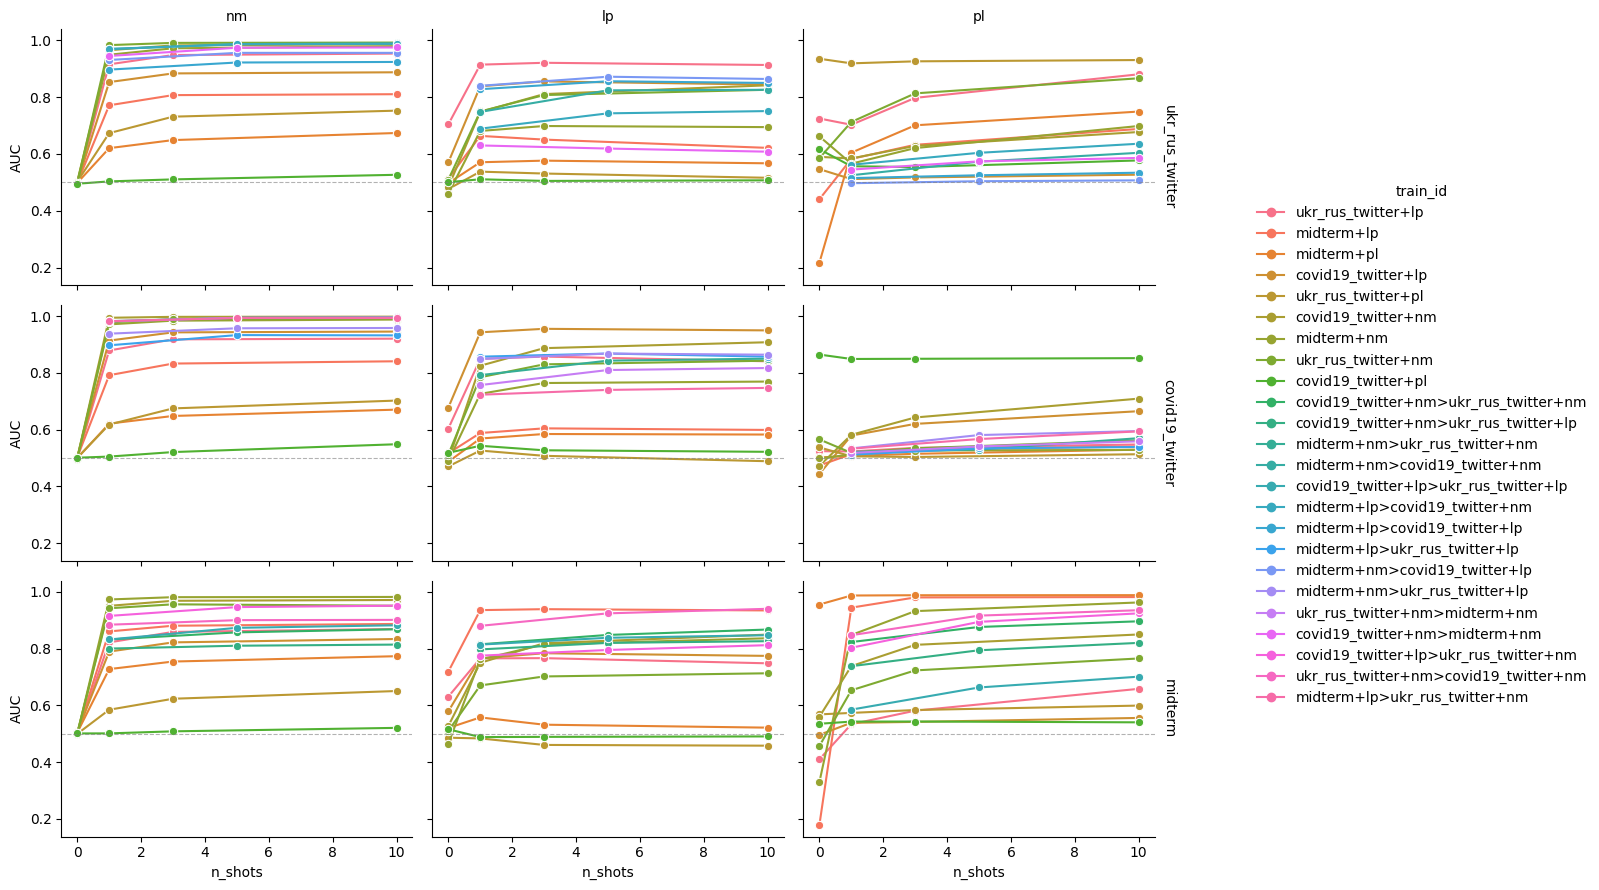

In [85]:
import seaborn as sns
import matplotlib.pyplot as plt

# split "dataset+task" -> two columns
df[['eval_dataset', 'eval_task']] = df['eval_id'].str.rsplit('+', n=1, expand=True)

g = sns.relplot(
    data=df.sort_values('n_shots'),
    x='n_shots', y='test_roc_auc',
    hue='train_id',
    row='eval_dataset', col='eval_task',
    kind='line', marker='o',
    height=3, aspect=1.4,
    facet_kws={'margin_titles': True},
    errorbar=None,  # drop if you want CIs when there are repeats
)
g.set_axis_labels('n_shots', 'AUC')
g.set_titles(row_template='{row_name}', col_template='{col_name}')
for ax in g.axes.flat:
    ax.axhline(0.5, ls='--', c='gray', lw=0.8, alpha=0.6)  # chance line
g.tight_layout()
plt.show()

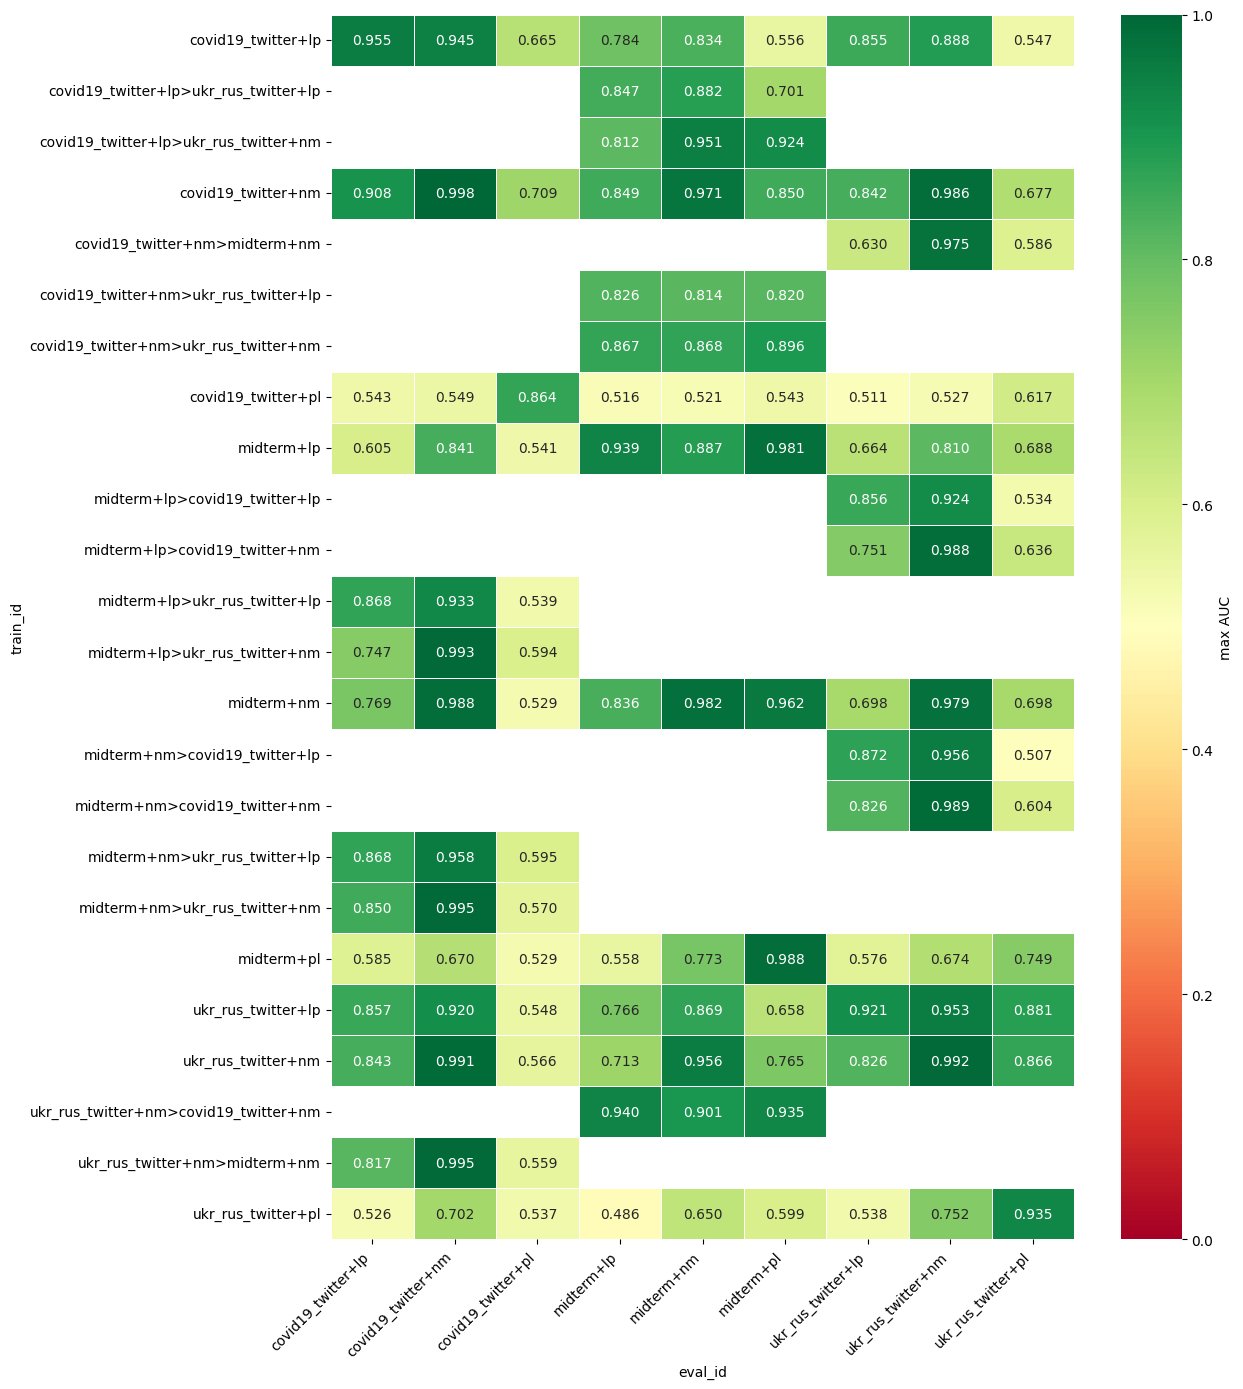

In [86]:
import seaborn as sns
import matplotlib.pyplot as plt

# TAKING BEST ACROSS SHOTS

# df.groupby('seq_id').test_roc_auc.transform('max')
max_df = df.sort_values('test_roc_auc', ascending=False).drop_duplicates(subset='seq_id')
plot_df = max_df[['train_id', 'eval_id', 'n_shots', 'test_roc_auc']].dropna()

plot_df = plot_df.sort_values('train_id')

# max AUC across n_shots for each (train_id, eval_id)
max_pivot = (plot_df.groupby(['train_id', 'eval_id'])['test_roc_auc']
           .max()
           .unstack('eval_id'))

fig, ax = plt.subplots(figsize=(1.2 * max_pivot.shape[1] + 2, 0.5 * max_pivot.shape[0] + 2))
sns.heatmap(
    max_pivot,
    annot=True, fmt='.3f',
    cmap='RdYlGn', vmin=0., vmax=1.0,  # 0.5 = chance, anchors the colormap meaningfully
    cbar_kws={'label': 'max AUC'},
    linewidths=0.5, linecolor='white',
    ax=ax,
)
ax.set_xlabel('eval_id')
ax.set_ylabel('train_id')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

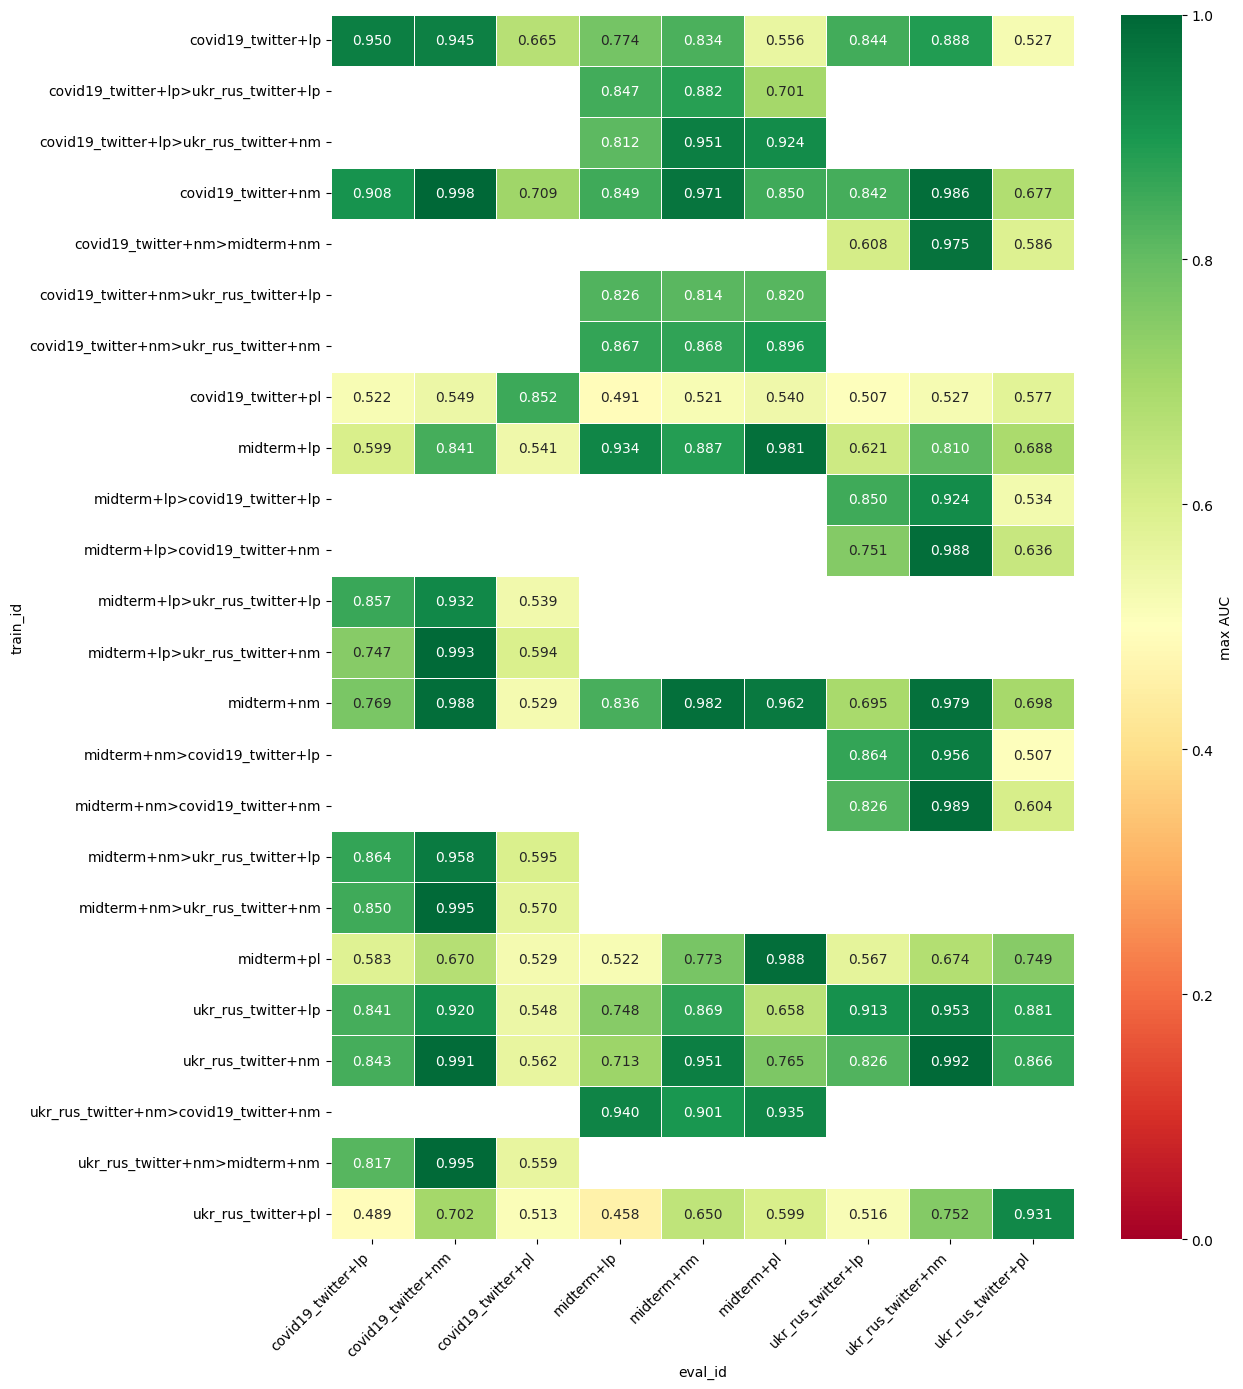

In [92]:
import seaborn as sns
import matplotlib.pyplot as plt

# TAKING @ 10 SHOTS

# df.groupby('seq_id').test_roc_auc.transform('max')
shot_df = df.sort_values('n_shots', ascending=False).drop_duplicates(subset='seq_id')
plot_df = shot_df[['train_id', 'eval_id', 'n_shots', 'test_roc_auc']].dropna()

plot_df = plot_df.sort_values('train_id')

# max AUC across n_shots for each (train_id, eval_id)
shot_pivot = (plot_df.groupby(['train_id', 'eval_id'])['test_roc_auc']
            .first()
           .unstack('eval_id'))

fig, ax = plt.subplots(figsize=(1.2 * shot_pivot.shape[1] + 2, 0.5 * shot_pivot.shape[0] + 2))
sns.heatmap(
    shot_pivot,
    annot=True, fmt='.3f',
    cmap='RdYlGn', vmin=0., vmax=1.0,  # 0.5 = chance, anchors the colormap meaningfully
    cbar_kws={'label': 'max AUC'},
    linewidths=0.5, linecolor='white',
    ax=ax,
)
ax.set_xlabel('eval_id')
ax.set_ylabel('train_id')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [448]:
shot_pivot.sub(shot_pivot.max(0)).mean(1).sort_values(key=abs)

/var/folders/6w/cs8z0j913k1d_x_ywtvrm5xc0000gp/T/ipykernel_44472/3828205945.py:1: Pandas4Warning: Starting with pandas version 4.0 all arguments of max will be keyword-only.
  shot_pivot.sub(shot_pivot.max(0)).mean(1).sort_values(key=abs)
/var/folders/6w/cs8z0j913k1d_x_ywtvrm5xc0000gp/T/ipykernel_44472/3828205945.py:1: Pandas4Warning: Starting with pandas version 4.0 all arguments of mean will be keyword-only.
  shot_pivot.sub(shot_pivot.max(0)).mean(1).sort_values(key=abs)


train_id
ukr_rus_twitter+nm>covid19_twitter+nm   -0.044615
covid19_twitter+lp>ukr_rus_twitter+nm   -0.074282
covid19_twitter+nm                      -0.083901
covid19_twitter+nm>ukr_rus_twitter+nm   -0.092948
ukr_rus_twitter+nm                      -0.115088
midterm+nm                              -0.122967
midterm+nm>ukr_rus_twitter+lp           -0.127415
midterm+nm>ukr_rus_twitter+nm           -0.128081
ukr_rus_twitter+lp                      -0.134887
midterm+nm>covid19_twitter+nm           -0.139064
ukr_rus_twitter+nm>midterm+nm           -0.142748
covid19_twitter+nm>ukr_rus_twitter+lp   -0.149948
midterm+lp>covid19_twitter+nm           -0.153731
midterm+lp>ukr_rus_twitter+nm           -0.155081
midterm+lp>ukr_rus_twitter+lp           -0.157081
covid19_twitter+lp>ukr_rus_twitter+lp   -0.159948
midterm+nm>covid19_twitter+lp           -0.169731
covid19_twitter+lp                      -0.173653
midterm+lp>covid19_twitter+lp           -0.176064
midterm+lp                              -

In [93]:
boost = {
    'dataset': {},
    'task': {},
    'dataset+task': {}
}

for train1_tuple in df.train1_tuple.unique():
    for eval_tuple in df.eval_tuple.unique():
        baseline = df[(df.train1_tuple == train1_tuple) & (df.eval_tuple == eval_tuple) & df.exp_name.eq('train1')]
        if baseline.empty:
            continue
        baseline_auc = baseline.test_roc_auc.values[0]

        with_additional = df[(df.train1_tuple == train1_tuple) & (df.eval_tuple == eval_tuple) & df.exp_name.eq('train2')]
        if with_additional.empty:
            continue
        with_additional_auc = with_additional.test_roc_auc.values[0]

        delta = with_additional_auc - baseline_auc

        train1_dataset, train1_task = train1_tuple.split('+')

        # dataset level
        boost['dataset'].setdefault(train1_dataset, {})[eval_tuple] = delta

        # task level
        boost['task'].setdefault(train1_task, {})[eval_tuple] = delta

        # dataset+task level
        boost['dataset+task'].setdefault(train1_tuple, {})[eval_tuple] = delta
    

In [94]:
import pandas as pd
import numpy as np
from itertools import combinations

def make_table(df, D1, D2, T1):
    datasets = sorted(set(df['eval_dataset'].dropna()) | set(df['train1_dataset'].dropna()))
    tasks    = sorted(set(df['eval_task'].dropna())    | set(df['train1_task'].dropna()))
    other_d  = [d for d in datasets if d not in (D1, D2)]
    other_t  = [t for t in tasks if t != T1]

    def mean_cell(filt):
        s = df
        for k, v in filt.items():
            s = s[s[k].isin(v)] if isinstance(v, list) else s[s[k] == v]
        return s['test_roc_auc'].mean() if len(s) else np.nan

    cols = {
        'D1T1': {'eval_dataset': D1,      'eval_task': T1},
        'D2T1': {'eval_dataset': D2,      'eval_task': T1},
        'DiT1': {'eval_dataset': other_d, 'eval_task': T1},
        'D1Ti': {'eval_dataset': D1,      'eval_task': other_t},
        'D2Ti': {'eval_dataset': D2,      'eval_task': other_t},
        'DiTj': {'eval_dataset': other_d, 'eval_task': other_t},
    }
    rows = {
        f'{D1}+{T1}|{eval_tuple}':
            {'exp_name': 'train1', 'train1_dataset': D1, 'train1_task': T1},
        f'{D2}+{T1}|':
            {'exp_name': 'train1', 'train1_dataset': D2, 'train1_task': T1},
        f'{D1}+{T1}>{D2}+{T1}|{eval_tuple}':
            {'exp_name': 'train2',
                       'train1_dataset': D1, 'train1_task': T1,
                       'train2_dataset': D2, 'train2_task': T1},
        f'{D2}+{T1}>{D1}+{T1}|{eval_tuple}':
            {'exp_name': 'train2',
                       'train1_dataset': D2, 'train1_task': T1,
                       'train2_dataset': D1, 'train2_task': T1},
    }

    out = pd.DataFrame(index=list(rows), columns=list(cols), dtype=float)
    for rn, rf in rows.items():
        for cn, cf in cols.items():
            out.loc[rn, cn] = mean_cell({**rf, **cf})
    return out

def all_tables(df):
    datasets = sorted(set(df['eval_dataset'].dropna()) | set(df['train1_dataset'].dropna()))
    tasks    = sorted(set(df['eval_task'].dropna())    | set(df['train1_task'].dropna()))
    return {
        (D1, D2, T1): make_table(df, D1, D2, T1)
        for D1, D2 in combinations(datasets, 2)
        for T1 in tasks
    }
    
tdf = df[df.n_shots.eq(10)]
tables = all_tables(tdf)

idx, tab = list(tables.items())[0]
tf = []
for idx, tab in tables.items():
    tab['idx'] = f"{idx[0]},{idx[1]},{idx[2]}"
    tab['model_tag'] = ['train1', 'train1', 'train2', 'train2']
    tf.append(tab)
final_df = pd.concat(tf)
final_df

,D1T1,D2T1,DiT1,D1Ti,D2Ti,DiTj,idx,model_tag
covid19_twitter+lp|covid19_twitter+nm,0.949569,0.774203,0.844235,0.805193,0.694714,0.707294,"covid19_twitter,midterm,lp",train1
midterm+lp|,0.599059,0.934279,0.621443,0.690674,0.934000,0.749219,"covid19_twitter,midterm,lp",train1
covid19_twitter+lp>midterm+lp|covid19_twitter+nm,NaN,NaN,NaN,NaN,NaN,NaN,"covid19_twitter,midterm,lp",train2
midterm+lp>covid19_twitter+lp|covid19_twitter+nm,NaN,NaN,0.850000,NaN,NaN,0.729000,"covid19_twitter,midterm,lp",train2
covid19_twitter+nm|covid19_twitter+nm,0.997874,0.971010,0.986411,0.808505,0.849433,0.759501,"covid19_twitter,midterm,nm",train1
midterm+nm|,0.987662,0.981776,0.979440,0.649085,0.899299,0.696469,"covid19_twitter,midterm,nm",train1
covid19_twitter+nm>midterm+nm|covid19_twitter+nm,NaN,NaN,0.975000,NaN,NaN,0.597000,"covid19_twitter,midterm,nm",train2
midterm+nm>covid19_twitter+nm|covid19_twitter+nm,NaN,NaN,0.989000,NaN,NaN,0.715000,"covid19_twitter,midterm,nm",train2
covid19_twitter+pl|covid19_twitter+nm,0.851801,0.540253,0.577193,0.535330,0.505698,0.516912,"covid19_twitter,midterm,pl",train1
midterm+pl|,0.529499,0.988069,0.749280,0.626641,0.647332,0.620423,"covid19_twitter,midterm,pl",train1


In [95]:
D = {}
tdf = df[df.n_shots.eq(10)]
for row in tdf[tdf.exp_name.eq('train2')].itertuples():
    D1 = row.train1_dataset
    T1 = row.train1_task
    TU1 = row.train1_tuple
    D2 = row.train2_dataset
    T2 = row.train2_task
    TU2 = row.train2_tuple
    E = row.eval_tuple
    ED = row.eval_dataset
    ET = row.eval_task
    
    i = (
        (tdf.eval_tuple.eq(E) & tdf.exp_name.eq('train1'))
        & (
        (tdf.train1_tuple.eq(TU1)) |
        (tdf.train1_tuple.eq(TU2))
    ))
    if i.sum() < 1:
        continue
    baselines = tdf[i]
    baselines['comparison_type'] = 'baseline'
    treatment = tdf.loc[row.Index].to_frame().T
    treatment['comparison_type'] = 'treatment'
    row_df = pd.concat([baselines, treatment],axis=0)
    row_df['comparison_id'] = row.seq_id
    D[row.seq_id] = row_df

# pd.concat([baselines, tdf.loc[row.Index]],axis=1)
cdf = pd.concat(D.values())
def f(g):
    treatment = g[g.comparison_type.eq('treatment')].iloc[0]
    baselines = g[g.comparison_type.eq('baseline')]
    delta = treatment.test_roc_auc - baselines.set_index('seq_id').test_roc_auc
    return delta
cdf = cdf.groupby('comparison_id').apply(f).reset_index()
cdf.columns = ['C1_id', 'C2_id', 'delta']
cdf[['C1_train1_tuple', 'C1_train2_tuple', 'C1_eval_tuple']] = cdf.C1_id.str.extract('(.+)>(.+)\|(.+)')
# cdf[['C1_train1_tuple', 'C2_train2_tuple']] = cdf.C1_train1_tuples.str.split('|', expand=True)
cdf[['C2_train1_tuple', 'C2_eval_tuple']] = cdf.C2_id.str.split('|', expand=True)
cdf[['C1_train1_dataset', 'C1_train1_task']] = cdf.C1_train1_tuple.str.split('+', expand=True)
cdf[['C1_train2_dataset', 'C1_train2_task']] = cdf.C1_train2_tuple.str.split('+', expand=True)
cdf[['C1_eval_dataset', 'C1_eval_task']] = cdf.C1_eval_tuple.str.split('+', expand=True)
cdf[['C2_train1_dataset', 'C2_train1_task']] = cdf.C1_train2_tuple.str.split('+', expand=True)
cdf[['C2_eval_dataset', 'C2_eval_task']] = cdf.C1_eval_tuple.str.split('+', expand=True)

cdf['train_datasets'] = cdf.C1_train1_dataset + "," + cdf.C1_train2_dataset + "," + cdf.C2_train1_dataset
cdf['train_datasets'] = cdf.train_datasets.str.split(',').apply(set)
cdf['train_tasks'] = cdf.C1_train1_task + "," + cdf.C1_train2_task + "," + cdf.C2_train1_task
cdf['train_tasks'] = cdf.train_tasks.str.split(',').apply(set)
cdf['eval_datasets'] = cdf.C1_eval_dataset + "," + cdf.C2_eval_dataset 
cdf['eval_datasets'] = cdf.eval_datasets.str.split(',').apply(set)
cdf['eval_tasks'] = cdf.C1_eval_task + "," + cdf.C2_eval_task
cdf['eval_tasks'] = cdf.eval_tasks.str.split(',').apply(set)

In [96]:
tdf[tdf.eval_tuple.isin(tdf[tdf.exp_name.eq('train2')].eval_tuple.unique())].groupby('exp_name').test_roc_auc.mean()

exp_name
train1    0.749470
train2    0.809933
Name: test_roc_auc, dtype: float64

In [97]:
# hold task fixed. 
cdf[(cdf.C1_train1_task == cdf.C1_train2_task) & (cdf.C1_train1_task == cdf.C1_eval_task) & (cdf.C1_train1_task == cdf.C2_eval_task)][['C1_id', 'C2_id', 'C1_train1_task', 'delta']].groupby('C1_train1_task').delta.mean()

C1_train1_task
lp    0.113381
nm    -0.02387
Name: delta, dtype: object

In [98]:
cdf['comp_tuple'] = cdf.apply(lambda x: [x.C1_train1_tuple, x.C1_train2_tuple], axis=1)
cdf = cdf.explode('comp_tuple')
cdf = cdf[cdf.comp_tuple == cdf.C2_train1_tuple]

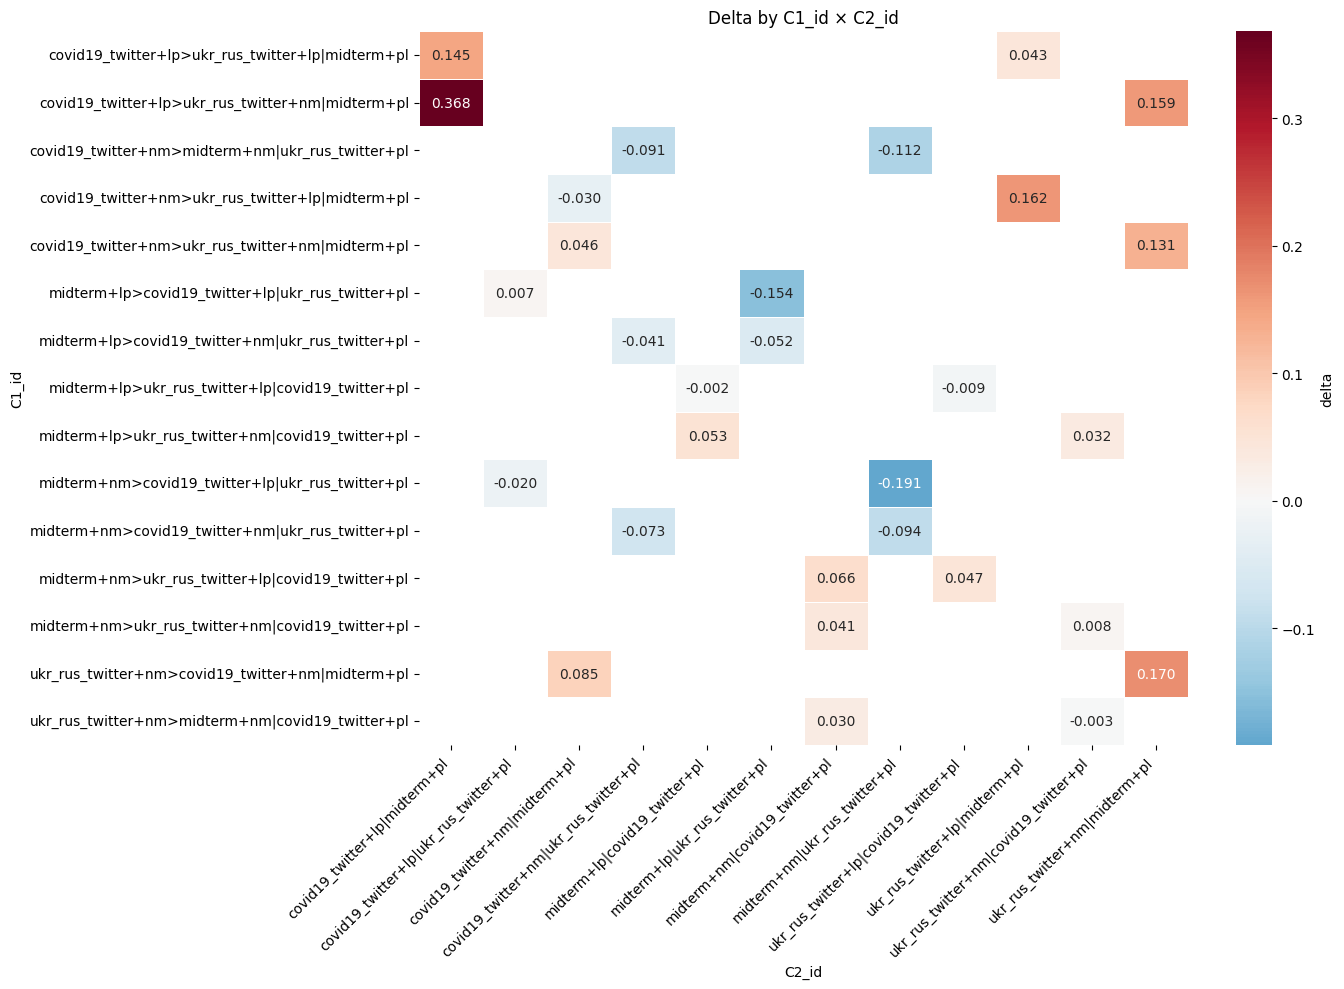

In [99]:
# cdf[['C1_id', 'C2_id', 'delta']]

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
cdf['delta'] = pd.to_numeric(cdf['delta'], errors='coerce')
# pivot: rows = C1_id, cols = C2_id, values = delta
pivot = cdf[cdf.C2_eval_task.eq('pl')][['C1_id', 'C2_id', 'delta']].pivot_table(index='C1_id', columns='C2_id', values='delta', aggfunc='mean')

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    pivot,
    cmap='RdBu_r',          # red = positive delta, blue = negative
    center=0,               # center colormap at 0 so sign is obvious
    annot=True, fmt='.3f',  # show values in cells
    linewidths=0.5,
    cbar_kws={'label': 'delta'},
    ax=ax,
)
ax.set_title('Delta by C1_id × C2_id')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [20]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

df = cdf.copy()
y = df['delta'].values

set_cols    = []
string_cols = [
               'C1_train1_dataset', 'C1_train1_task',
               'C1_train2_dataset', 'C1_train2_task',
               'C1_eval_dataset',   'C1_eval_task',
               'C2_train1_dataset', 'C2_train1_task',
               'C2_eval_dataset',   'C2_eval_task',]

feature_frames = []

# 1) expand set columns: each element -> its own 0/1 column
for col in set_cols:
    # make sure values are actually sets/lists (not stringified)
    vals = df[col].apply(lambda s: s if isinstance(s, (set, list, frozenset)) else set(s))
    mlb = MultiLabelBinarizer()
    arr = mlb.fit_transform(vals)
    feature_frames.append(
        pd.DataFrame(arr, columns=[f"{col}={c}" for c in mlb.classes_], index=df.index)
    )

# 2) one-hot encode string columns
feature_frames.append(pd.get_dummies(df[string_cols], prefix=string_cols))

X = pd.concat(feature_frames, axis=1).astype(float)

# 3) fit model
rf = RandomForestRegressor(n_estimators=500, random_state=0, n_jobs=-1)
rf.fit(X, y)

# impurity-based importance (fast but biased toward high-cardinality features)
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Top features (impurity):")
print(imp.head(20))

# permutation importance (more reliable)
perm = permutation_importance(rf, X, y, n_repeats=30, random_state=0, n_jobs=-1)
perm_imp = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)
print("\nTop features (permutation):")
print(perm_imp.head(20))

Top features (impurity):
C2_eval_task_lp                      0.124404
C1_eval_task_lp                      0.104557
C1_train1_task_nm                    0.084871
C1_train1_task_lp                    0.078582
C2_eval_task_pl                      0.063184
C2_eval_task_nm                      0.059283
C1_eval_task_pl                      0.059085
C1_eval_task_nm                      0.054277
C1_train1_dataset_midterm            0.034557
C1_train1_dataset_covid19_twitter    0.031638
C2_eval_dataset_midterm              0.031442
C1_eval_dataset_midterm              0.027541
C2_eval_dataset_ukr_rus_twitter      0.024059
C1_eval_dataset_ukr_rus_twitter      0.024043
C1_train2_dataset_covid19_twitter    0.022368
C1_train2_dataset_ukr_rus_twitter    0.021672
C2_train1_dataset_ukr_rus_twitter    0.021526
C2_train1_task_lp                    0.020995
C2_train1_task_nm                    0.019811
C2_train1_dataset_covid19_twitter    0.019170
dtype: float64

Top features (permutation):
C2_eval_tas

In [21]:
# i = final_df[["D1T1",	"D2T1",	"DiT1",	"D1Ti",	"D2Ti",	"DiTj",]].isna().all(1)
cols = ["D1T1",	"D2T1",	"DiT1",	"D1Ti",	"D2Ti",	"DiTj",]
# final_df = final_df[~i]
def f(g_):
    g = g_[cols]
    i = g.index
    # does adding a D help?
    n = {
        f"{i[2]} - {i[0]}": g.iloc[2] - g.iloc[0],
        f"{i[2]} - {i[1]}": g.iloc[2] - g.iloc[1],
        f"{i[3]} - {i[0]}": g.iloc[3] - g.iloc[0],
        f"{i[3]} - {i[1]}": g.iloc[3] - g.iloc[1],
    }
    n =  pd.DataFrame(n).T
    n['source_train2'] = [i[2],i[2], i[3], i[3]]
    return n
    
final_df['added_dataset'] = final_df.index.str.findall('\>(.+)\+').str[0]
final_df['added_task'] = final_df.index.str.findall('\>.+\+(.+)').str[0]
cdf = (final_df
    .groupby('idx').apply(f)
    # .groupby('source_train2')[cols].mean()
)
cdf = cdf[~cdf[cols].isna().all(1)][cols]
#.mean(0)
cdf = cdf.reset_index()
cdf['C1_seq'] = cdf.level_1.str.split(' - ').str[0]
cdf['C1_train_seq'] = cdf.C1_seq.str.split('|').str[0]
cdf['C1_eval_tuple'] = cdf.C1_seq.str.split('|').str[1]
cdf['C1_train1_tuple'] = cdf.C1_seq.str.split('>').str[0]
cdf['C1_train2_tuple'] = cdf.C1_seq.str.split('>').str[1]

cdf['C2_seq'] = cdf.level_1.str.split(' - ').str[0]
cdf['C2_train_seq'] = cdf.C2_seq.str.split('|').str[0]
cdf['C2_eval_tuple'] = cdf.C2_seq.str.split('|').str[1]
cdf['C2_train1_tuple'] = cdf.C2_seq.str.split('>').str[0]
cdf['C2_train2_tuple'] = cdf.C2_seq.str.split('>').str[1]
# del cdf['level_1']
final_df

/var/folders/6w/cs8z0j913k1d_x_ywtvrm5xc0000gp/T/ipykernel_44472/891285224.py:24: Pandas4Warning: Starting with pandas version 4.0 all arguments of all will be keyword-only.
  cdf = cdf[~cdf[cols].isna().all(1)][cols]


,D1T1,D2T1,DiT1,D1Ti,D2Ti,DiTj,idx,model_tag,added_dataset,added_task
covid19_twitter+lp|covid19_twitter+nm,0.949569,0.774203,0.844235,0.805193,0.694714,0.707294,"covid19_twitter,midterm,lp",train1,NaN,NaN
midterm+lp|,0.599059,0.934279,0.621443,0.690674,0.934000,0.749219,"covid19_twitter,midterm,lp",train1,NaN,NaN
covid19_twitter+lp>midterm+lp|covid19_twitter+nm,NaN,NaN,NaN,NaN,NaN,NaN,"covid19_twitter,midterm,lp",train2,midterm+lp|covid19_twitter,nm
midterm+lp>covid19_twitter+lp|covid19_twitter+nm,NaN,NaN,0.850000,NaN,NaN,0.729000,"covid19_twitter,midterm,lp",train2,covid19_twitter+lp|covid19_twitter,nm
covid19_twitter+nm|covid19_twitter+nm,0.997874,0.971010,0.986411,0.808505,0.849433,0.759501,"covid19_twitter,midterm,nm",train1,NaN,NaN
midterm+nm|,0.987662,0.981776,0.979440,0.649085,0.899299,0.696469,"covid19_twitter,midterm,nm",train1,NaN,NaN
covid19_twitter+nm>midterm+nm|covid19_twitter+nm,NaN,NaN,NaN,NaN,NaN,NaN,"covid19_twitter,midterm,nm",train2,midterm+nm|covid19_twitter,nm
midterm+nm>covid19_twitter+nm|covid19_twitter+nm,NaN,NaN,0.989000,NaN,NaN,0.715000,"covid19_twitter,midterm,nm",train2,covid19_twitter+nm|covid19_twitter,nm
covid19_twitter+pl|covid19_twitter+nm,0.851801,0.540253,0.577193,0.535330,0.505698,0.516912,"covid19_twitter,midterm,pl",train1,NaN,NaN
midterm+pl|,0.529499,0.988069,0.749280,0.626641,0.647332,0.620423,"covid19_twitter,midterm,pl",train1,NaN,NaN


## again yay

## does order matter?

In [194]:
order_df = []
# does order matter
for i, row in tdf[tdf.exp_name.eq('train2')].iterrows():
    T1 = row.train1_tuple
    T2 = row.train2_tuple
    E = row.eval_tuple
    mask = (
        tdf.train1_tuple.eq(T2) &
        tdf.train2_tuple.eq(T1) &
        tdf.eval_tuple.eq(E) 
    )
    if tdf[mask].shape[0] == 1:
        delta = tdf.loc[i].test_roc_auc - tdf[mask].iloc[0].test_roc_auc
        s = pd.Series({"Train1": T1, "Train2": T2, "Eval": E, 'A>B - B>A': delta, "Both": frozenset([T1, T2]), "delta": delta})
        order_df.append(s)
    elif tdf[mask].shape[0] > 1:
        raise '1'
        
order_df = pd.DataFrame(order_df)
order_df.sort_values(["Eval", 'Train1']).drop_duplicates(['Both', 'Eval'])[['Train1', 'Train2', 'Eval', 'delta']]

,Train1,Train2,Eval,delta
4,midterm+nm,ukr_rus_twitter+nm,covid19_twitter+lp,0.033
3,midterm+nm,ukr_rus_twitter+nm,covid19_twitter+nm,0.000
5,midterm+nm,ukr_rus_twitter+nm,covid19_twitter+pl,0.011
7,covid19_twitter+nm,ukr_rus_twitter+nm,midterm+lp,-0.073
6,covid19_twitter+nm,ukr_rus_twitter+nm,midterm+nm,-0.033
8,covid19_twitter+nm,ukr_rus_twitter+nm,midterm+pl,-0.039
10,covid19_twitter+nm,midterm+nm,ukr_rus_twitter+lp,-0.218
9,covid19_twitter+nm,midterm+nm,ukr_rus_twitter+nm,-0.014
11,covid19_twitter+nm,midterm+nm,ukr_rus_twitter+pl,-0.018


# impact of a new dataset

### impact of a second dataset on the same dataset and task


**Control:**

D1T1 | D1T1

**Treatment:**

D1T1 > D2T1

D2T1 > D1T1

In [196]:
dfs = []
for i, row in tdf[tdf.exp_name.eq('train1')].iterrows():
    if row.train1_tuple != row.eval_tuple:
        continue
    mask = (
        tdf.exp_name.eq('train2') &
        (tdf.train1_tuple.eq(row.train1_tuple) & tdf.train2_task.eq(row.train1_task) & tdf.eval_tuple.eq(row.eval_tuple)) |
        (tdf.train2_tuple.eq(row.train1_tuple) & tdf.train1_task.eq(row.train1_task) & tdf.eval_tuple.eq(row.eval_tuple))
    )
    if tdf[mask].shape[0] > 0:
        # display(tdf[mask])
        deltas = (tdf[mask].test_roc_auc - row.test_roc_auc)
        tdf.loc[mask, 'delta'] = deltas
        tdf.loc[mask, 'compared_to'] = row.seq_id
        tdf.loc[mask, 'added'] = tdf['train2_tuple']
        dfs.append(tdf[mask])
        # print(row.seq_id)
        # print(deltas)
        # print() 
        # means.append(deltas.mean())

len(dfs)
# print(pd.concat(dfs)[['seq_id', 'compared_to', 'delta']].delta.mean())
# pd.concat(dfs)[['compared_to', 'added', 'seq_id', 'delta']].sort_values('added')

0

### impact of a second dataset on the same dataset, new task


**Control:**

D1T1 | D1T2

**Treatment:**

D1T1 > D2T1

D2T1 > D1T1

In [197]:
dfs = []
for i, row in tdf[tdf.exp_name.eq('train1')].iterrows():
    if row.train1_tuple != row.eval_tuple:
        continue
    mask = (
        tdf.exp_name.eq('train2') &
        (tdf.train1_tuple.eq(row.train1_tuple) & tdf.train2_task.eq(row.train1_task) & tdf.eval_tuple.eq(row.eval_tuple)) |
        (tdf.train2_tuple.eq(row.train1_tuple) & tdf.train1_task.eq(row.train1_task) & tdf.eval_tuple.eq(row.eval_tuple))
    )
    if tdf[mask].shape[0] > 0:
        # display(tdf[mask])
        deltas = (tdf[mask].test_roc_auc - row.test_roc_auc)
        tdf.loc[mask, 'delta'] = deltas
        tdf.loc[mask, 'compared_to'] = row.seq_id
        tdf.loc[mask, 'added'] = tdf['train2_tuple']
        dfs.append(tdf[mask])
        # print(row.seq_id)
        # print(deltas)
        # print() 
        # means.append(deltas.mean())
# pd.Series(means).mean()
len(dfs)
# print(pd.concat(dfs)[['seq_id', 'compared_to', 'delta']].delta.mean())
# pd.concat(dfs)[['compared_to', 'added', 'seq_id', 'delta']].sort_values('added')

0

### impact of a second dataset on the same task, new dataset


**Control:**

D1T1 | D2T1

**Treatment:**

D1T1 > D3T1

D3T1 > D1T1

...*where 3 != 2*

In [198]:
dfs = []
for i, row in tdf[tdf.exp_name.eq('train1')].iterrows():
    if row.train1_tuple != row.eval_tuple:
        continue
    mask = (
        tdf.exp_name.eq('train2') &
        (tdf.train1_tuple.eq(row.train1_tuple) & tdf.train2_task.eq(row.train1_task) & tdf.eval_tuple.eq(row.eval_tuple)) |
        (tdf.train2_tuple.eq(row.train1_tuple) & tdf.train1_task.eq(row.train1_task) & tdf.eval_tuple.eq(row.eval_tuple))
    )
    if tdf[mask].shape[0] > 0:
        # display(tdf[mask])
        deltas = (tdf[mask].test_roc_auc - row.test_roc_auc)
        tdf.loc[mask, 'delta'] = deltas
        tdf.loc[mask, 'compared_to'] = row.seq_id
        tdf.loc[mask, 'added'] = tdf['train2_tuple']
        dfs.append(tdf[mask])
        # print(row.seq_id)
        # print(deltas)
        # print() 
        # means.append(deltas.mean())
# pd.Series(means).mean()
len(dfs)
# print(pd.concat(dfs)[['seq_id', 'compared_to', 'delta']].delta.mean())
# pd.concat(dfs)[['compared_to', 'added', 'seq_id', 'delta']].sort_values('added')

0

#### what if D2 = D3



**Control:**

D1T1 | D2T1

**Treatment:**

D1T1 > D2T1

D2T1 > D1T1

...*where 3 == 2*

In [ ]:
dfs = []
for i, row in tdf[tdf.exp_name.eq('train1')].iterrows():
    if row.train1_tuple != row.eval_tuple:
        continue
    mask = (
        tdf.exp_name.eq('train2') &
        (tdf.train1_tuple.eq(row.train1_tuple) & tdf.train2_task.eq(row.train1_task) & tdf.eval_tuple.eq(row.eval_tuple)) |
        (tdf.train2_tuple.eq(row.train1_tuple) & tdf.train1_task.eq(row.train1_task) & tdf.eval_tuple.eq(row.eval_tuple))
    )
    if tdf[mask].shape[0] > 0:
        # display(tdf[mask])
        deltas = (tdf[mask].test_roc_auc - row.test_roc_auc)
        tdf.loc[mask, 'delta'] = deltas
        tdf.loc[mask, 'compared_to'] = row.seq_id
        tdf.loc[mask, 'added'] = tdf['train2_tuple']
        dfs.append(tdf[mask])
        # print(row.seq_id)
        # print(deltas)
        # print() 
        # means.append(deltas.mean())
# pd.Series(means).mean()

# print(pd.concat(dfs)[['seq_id', 'compared_to', 'delta']].delta.mean())
# pd.concat(dfs)[['compared_to', 'added', 'seq_id', 'delta']].sort_values('added')

### impact of a second dataset on the same task, new dataset

**Control:**

D1T1 | D2T1

**Treatment:**

D1T1 > D3T1

D3T1 > D1T1

...*where 3 != 2*

In [199]:
dfs = []
for i, row in tdf[tdf.exp_name.eq('train1')].iterrows():
    if row.train1_tuple != row.eval_tuple:
        continue
    mask = (
        tdf.exp_name.eq('train2') &
        (tdf.train1_tuple.eq(row.train1_tuple) & tdf.train2_task.eq(row.train1_task) & tdf.eval_tuple.eq(row.eval_tuple)) |
        (tdf.train2_tuple.eq(row.train1_tuple) & tdf.train1_task.eq(row.train1_task) & tdf.eval_tuple.eq(row.eval_tuple))
    )
    if tdf[mask].shape[0] > 0:
        # display(tdf[mask])
        deltas = (tdf[mask].test_roc_auc - row.test_roc_auc)
        tdf.loc[mask, 'delta'] = deltas
        tdf.loc[mask, 'compared_to'] = row.seq_id
        tdf.loc[mask, 'added'] = tdf['train2_tuple']
        dfs.append(tdf[mask])
        # print(row.seq_id)
        # print(deltas)
        # print() 
        # means.append(deltas.mean())
# pd.Series(means).mean()
len(dfs)
# print(pd.concat(dfs)[['seq_id', 'compared_to', 'delta']].delta.mean())
# pd.concat(dfs)[['compared_to', 'added', 'seq_id', 'delta']].sort_values('added')

0

# impact of a new task

**Control:**

D1T1 | D1T1

**Treatment:**

D1T1 > D1T2

D1T2 > D1T1

idk

impact of a new dataset on the same dataset+task

treatment: DiTj + DkTj

control: DiTj

Y: DiTj

In [302]:
rows = []
datasets = tdf.train1_dataset.unique()
tasks = tdf.train1_task.unique()

def auc_for(seq_id):
    match = tdf.loc[tdf.seq_id.eq(seq_id), "test_roc_auc"]
    if len(match) != 1:
        raise ValueError(f"Expected 1 row for {seq_id}, got {len(match)}")
    return match.iloc[0]

for Di in datasets:
    for Tj in tasks:
        DiTj = f"{Di}+{Tj}"

        control_id = f"{DiTj}|{DiTj}"
        control_auc = auc_for(control_id)

        for Dk in datasets:
            if Dk == Di:
                continue

            DkTj = f"{Dk}+{Tj}"

            treatment_ids = [
                f"{DiTj}>{DkTj}|{DiTj}",
                f"{DkTj}>{DiTj}|{DiTj}",
            ]

            for treatment_id in treatment_ids:
                treatment_auc = tdf.loc[
                    tdf.seq_id.eq(treatment_id), "test_roc_auc"
                ]

                if not treatment_auc.empty:
                    rows.append({
                        "control": control_id,
                        "treatment": treatment_id,
                        "delta": treatment_auc.mean() - control_auc,
                        "y": DiTj,
                    })

DiTj = None
try:
    DiTj = pd.DataFrame(rows).delta.mean()
except:
    pass

impact of a new task on the same dataset, new task

treatment: DiTj + DkTj

control: DiTj

Y: DiTn

In [ ]:
rows = []
datasets = tdf.train1_dataset.unique()
tasks = tdf.train1_task.unique()

def auc_for(seq_id):
    match = tdf.loc[tdf.seq_id.eq(seq_id), "test_roc_auc"]
    if len(match) != 1:
        raise ValueError(f"Expected 1 row for {seq_id}, got {len(match)}")
    return match.iloc[0]

for Di in datasets:
    for Tj in tasks:
        DiTj = f"{Di}+{Tj}"

        for Tn in tasks:
            if Tn == Tj:
                continue

            DiTn = f"{Di}+{Tn}"
            control_id = f"{DiTj}|{DiTn}"
            control_auc = auc_for(control_id)

            for Dk in datasets:
                if Dk == Di:
                    continue

                DkTj = f"{Dk}+{Tj}"

                treatment_ids = [
                    f"{DiTj}>{DkTj}|{DiTn}",
                    f"{DkTj}>{DiTj}|{DiTn}",
                ]

                for treatment_id in treatment_ids:
                    treatment_auc = tdf.loc[
                        tdf.seq_id.eq(treatment_id), "test_roc_auc"
                    ]

                    if not treatment_auc.empty:
                        rows.append({
                            "control": control_id,
                            "treatment": treatment_id,
                            "delta": treatment_auc.mean() - control_auc,
                            "y": DiTn,
                        })

DiTn = None
try:
    DiTn = pd.DataFrame(rows).delta.mean()
except:
    pass

impact of a new task on a new dataset, same task

treatment: DiTj + DkTj

control: DiTj

Y: DnTj

In [304]:
rows = []
datasets = tdf.train1_dataset.unique()
tasks = tdf.train1_task.unique()

def auc_for(seq_id):
    match = tdf.loc[tdf.seq_id.eq(seq_id), "test_roc_auc"]
    if len(match) != 1:
        raise ValueError(f"Expected 1 row for {seq_id}, got {len(match)}")
    return match.iloc[0]

for Di in datasets:
    for Tj in tasks:
        DiTj = f"{Di}+{Tj}"

        for Dn in datasets:
            if Dn == Di:
                continue

            DnTj = f"{Dn}+{Tj}"
            control_id = f"{DiTj}|{DnTj}"
            control_auc = auc_for(control_id)

            for Dk in datasets:
                if Dk == Di:
                    continue

                DkTj = f"{Dk}+{Tj}"
                treatment_ids = [
                    f"{DiTj}>{DkTj}|{DnTj}",
                    f"{DkTj}>{DiTj}|{DnTj}",
                ]

                for treatment_id in treatment_ids:
                    treatment_auc = tdf.loc[
                        tdf.seq_id.eq(treatment_id), "test_roc_auc"
                    ]

                    if not treatment_auc.empty:
                        rows.append({
                            "control": control_id,
                            "treatment": treatment_id,
                            "delta": treatment_auc.mean() - control_auc,
                        })

DnTj = None
try:
    DnTj = pd.DataFrame(rows).delta.mean()
except:
    pass

impact of a new task on a new dataset, new task

treatment: DiTj + DkTj

control: DiTj

Y: DnTn

In [305]:
rows = []
datasets = tdf.train1_dataset.unique()
tasks = tdf.train1_task.unique()

def auc_for(seq_id):
    match = tdf.loc[tdf.seq_id.eq(seq_id), "test_roc_auc"]
    if len(match) != 1:
        raise ValueError(f"Expected 1 row for {seq_id}, got {len(match)}")
    return match.iloc[0]

for Di in datasets:
    for Tj in tasks:
        DiTj = f"{Di}+{Tj}"

        for Dn in datasets:
            if Dn == Di:
                continue

            for Tn in tasks:
                if Tn == Tj:
                    continue

                DnTn = f"{Dn}+{Tn}"
                control_id = f"{DiTj}|{DnTn}"
                control_auc = auc_for(control_id)

                for Dk in datasets:
                    if Dk == Di:
                        continue

                    DkTj = f"{Dk}+{Tj}"

                    treatment_ids = [
                        f"{DiTj}>{DkTj}|{DnTn}",
                        f"{DkTj}>{DiTj}|{DnTn}",
                    ]

                    for treatment_id in treatment_ids:
                        treatment_auc = tdf.loc[
                            tdf.seq_id.eq(treatment_id), "test_roc_auc"
                        ]

                        if not treatment_auc.empty:
                            rows.append({
                                "control": control_id,
                                "treatment": treatment_id,
                                "delta": treatment_auc.mean() - control_auc,
                                "y": DnTn,
                            })

DnTn = None
try:
    DnTn = pd.DataFrame(rows).delta.mean()
except:
    pass

In [327]:
import pandas as pd

datasets = tdf.train1_dataset.unique()
tasks = tdf.train1_task.unique()

def seq_auc(seq_id):
    vals = tdf.loc[tdf.seq_id.eq(seq_id), "test_roc_auc"]
    return vals.mean() if len(vals) else None

def regime(Di, Tj, D, T):
    if D == Di and T == Tj:
        return "DiTj"
    if D != Di and T == Tj:
        return "DnTj"
    if D == Di and T != Tj:
        return "DiTn"
    return "DnTn"

rows = []

for Di in datasets:
    for Tj in tasks:
        DiTj = f"{Di}+{Tj}"

        # eval targets Y
        for Dn in datasets:
            for Tn in tasks:
                Y = f"{Dn}+{Tn}"
                eval_regime = regime(Di, Tj, Dn, Tn)

                control_id = f"{DiTj}|{Y}"
                control_auc = seq_auc(control_id)

                if control_auc is None:
                    continue

                # include control as delta 0
                rows.append({
                    "treatment_type": "control (DiTj)",
                    "eval_regime": eval_regime,
                    "delta": 0.0,
                    "control": control_id,
                    "treatment": control_id,
                })

                # +dataset: DiTj + DkTj
                for Dk in datasets:
                    if Dk == Di:
                        continue

                    DkTj = f"{Dk}+{Tj}"
                    treatment_ids = [
                        f"{DiTj}>{DkTj}|{Y}",
                        f"{DkTj}>{DiTj}|{Y}",
                    ]

                    for tid in treatment_ids:
                        auc = seq_auc(tid)
                        if auc is not None:
                            rows.append({
                                "treatment_type": "+dataset (DiTj+DkTj)",
                                "eval_regime": eval_regime,
                                "delta": auc - control_auc,
                                "control": control_id,
                                "treatment": tid,
                            })

                # +task: DiTj + DiTk
                for Tk in tasks:
                    if Tk == Tj:
                        continue

                    DiTk = f"{Di}+{Tk}"
                    treatment_ids = [
                        f"{DiTj}>{DiTk}|{Y}",
                        f"{DiTk}>{DiTj}|{Y}",
                    ]

                    for tid in treatment_ids:
                        auc = seq_auc(tid)
                        if auc is not None:
                            rows.append({
                                "treatment_type": "+task (DiTj+DiTk)",
                                "eval_regime": eval_regime,
                                "delta": auc - control_auc,
                                "control": control_id,
                                "treatment": tid,
                            })

                # +dataset, +task: DiTj + DkTl
                for Dk in datasets:
                    if Dk in (Di, Dn):
                        continue

                    for Tl in tasks:
                        if Tl in (Tj, Tn):
                            continue

                        DkTl = f"{Dk}+{Tl}"
                        treatment_ids = [
                            f"{DiTj}>{DkTl}|{Y}",
                            f"{DkTl}>{DiTj}|{Y}",
                        ]

                        for tid in treatment_ids:
                            auc = seq_auc(tid)
                            if auc is not None:
                                rows.append({
                                    "treatment_type": "+dataset, +task (DiTj+DkTl)",
                                    "eval_regime": eval_regime,
                                    "delta": auc - control_auc,
                                    "control": control_id,
                                    "treatment": tid,
                                })

long = pd.DataFrame(rows)

table = (
    long
    .groupby(["treatment_type", "eval_regime"])["delta"]
    .mean()
    .unstack("eval_regime")
    .reindex(
        index=[
            "control (DiTj)",
            "+dataset (DiTj+DkTj)",
            "+task (DiTj+DiTk)",
            "+dataset, +task (DiTj+DkTl)",
        ],
        columns=["DiTj", "DnTj", "DiTn", "DnTn"],
    )
)

table

eval_regime,DiTj,DnTj,DiTn,DnTn
treatment_type,,,,
control (DiTj),0.0,0.000000,0.0,0.000000
+dataset (DiTj+DkTj),NaN,0.021881,NaN,0.024352
+task (DiTj+DiTk),NaN,NaN,NaN,NaN
"+dataset, +task (DiTj+DkTl)",NaN,0.019172,NaN,0.046092


In [361]:
rows = []

def parse_pair(x):
    D, T = x.split("+", 1)
    return D, T

def seq_auc(seq_id):
    vals = tdf.loc[tdf.seq_id.eq(seq_id), "test_roc_auc"]
    return vals.mean() if len(vals) else None

for seq_id in tdf.seq_id:
    if ">" not in seq_id:
        continue

    train_part, C_full = seq_id.split("|")
    A_full, B_full = train_part.split(">")

    _, A = parse_pair(A_full)
    _, B = parse_pair(B_full)
    _, C = parse_pair(C_full)

    control_id = f"{A_full}|{C_full}"
    control_auc = seq_auc(control_id)
    treatment_auc = seq_auc(seq_id)

    if control_auc is None or treatment_auc is None:
        continue

    rows.append({
        "train_transfer": f"{A}>{B}",
        "eval_task": C,
        "delta": treatment_auc - control_auc,
    })

long = pd.DataFrame(rows)

delta_matrix = (
    long
    .groupby(["train_transfer", "eval_task"])["delta"]
    .mean()
    .unstack("eval_task")
)

delta_matrix

eval_task,lp,nm,pl
train_transfer,,,
lp>lp,0.186432,0.084385,-0.003456
lp>nm,0.105098,0.149051,0.123211
nm>lp,0.080311,-0.070038,-0.051636
nm>nm,0.032908,-0.023870,0.011404


In [364]:
rows = []

def parse_pair(x):
    D, T = x.split("+", 1)
    return D, T

def seq_auc(seq_id):
    vals = tdf.loc[tdf.seq_id.eq(seq_id), "test_roc_auc"]
    return vals.mean() if len(vals) else None

for seq_id in tdf.seq_id:
    if ">" not in seq_id:
        continue

    train_part, C_full = seq_id.split("|")
    A_full, B_full = train_part.split(">")

    A_dataset, _ = parse_pair(A_full)
    B_dataset, _ = parse_pair(B_full)
    C_dataset, _ = parse_pair(C_full)

    control_id = f"{A_full}|{C_full}"
    control_auc = seq_auc(control_id)
    treatment_auc = seq_auc(seq_id)

    if control_auc is None or treatment_auc is None:
        continue

    rows.append({
        "train_transfer": f"{A_dataset}>{B_dataset}",
        "eval_dataset": C_dataset,
        "delta": treatment_auc - control_auc,
    })

long_dataset_delta = pd.DataFrame(rows)

dataset_delta_matrix = (
    long_dataset_delta
    .groupby(["train_transfer", "eval_dataset"])["delta"]
    .mean()
    .unstack("eval_dataset")
)

dataset_delta_matrix

eval_dataset,covid19_twitter,midterm,ukr_rus_twitter
train_transfer,,,
covid19_twitter>midterm,NaN,NaN,-0.112137
covid19_twitter>ukr_rus_twitter,NaN,0.045082,NaN
midterm>covid19_twitter,NaN,NaN,0.037040
midterm>ukr_rus_twitter,0.080127,NaN,NaN
ukr_rus_twitter>covid19_twitter,NaN,0.115710,NaN
ukr_rus_twitter>midterm,-0.008328,NaN,NaN


In [365]:
rows = []

def parse_pair(x):
    D, T = x.split("+", 1)
    return D, T

def seq_auc(seq_id):
    vals = tdf.loc[tdf.seq_id.eq(seq_id), "test_roc_auc"]
    return vals.mean() if len(vals) else None

for seq_id in tdf.seq_id:
    if ">" not in seq_id:
        continue

    train_part, C_full = seq_id.split("|")
    A_full, B_full = train_part.split(">")

    A_dataset, _ = parse_pair(A_full)
    B_dataset, _ = parse_pair(B_full)
    C_dataset, _ = parse_pair(C_full)

    # unordered pair
    pair = tuple(sorted([A_dataset, B_dataset]))

    control_id = f"{A_full}|{C_full}"
    control_auc = seq_auc(control_id)
    treatment_auc = seq_auc(seq_id)

    if control_auc is None or treatment_auc is None:
        continue

    rows.append({
        "train_pair": pair,
        "eval_dataset": C_dataset,
        "delta": treatment_auc - control_auc,
    })

long = pd.DataFrame(rows)

matrix = (
    long
    .groupby(["train_pair", "eval_dataset"])["delta"]
    .mean()
    .unstack("eval_dataset")
)

matrix

eval_dataset,covid19_twitter,midterm,ukr_rus_twitter
train_pair,,,
"(covid19_twitter, midterm)",NaN,NaN,0.007205
"(covid19_twitter, ukr_rus_twitter)",NaN,0.059208,NaN
"(midterm, ukr_rus_twitter)",0.062436,NaN,NaN


In [366]:
rows = []

def parse_pair(x):
    D, T = x.split("+", 1)
    return D, T

def seq_auc(seq_id):
    vals = tdf.loc[tdf.seq_id.eq(seq_id), "test_roc_auc"]
    return vals.mean() if len(vals) else None

for seq_id in tdf.seq_id:
    if ">" not in seq_id:
        continue

    train_part, C_full = seq_id.split("|")
    A_full, B_full = train_part.split(">")

    A_dataset, A_task = parse_pair(A_full)
    B_dataset, B_task = parse_pair(B_full)
    C_dataset, C_task = parse_pair(C_full)

    control_id = f"{A_full}|{C_full}"
    control_auc = seq_auc(control_id)
    treatment_auc = seq_auc(seq_id)

    if control_auc is None or treatment_auc is None:
        continue

    rows.append({
        "dataset_order": f"{A_dataset}>{B_dataset}",
        "eval_task": C_task,
        "delta": treatment_auc - control_auc,
    })

long_order_task = pd.DataFrame(rows)

order_task_matrix = (
    long_order_task
    .groupby(["dataset_order", "eval_task"])["delta"]
    .mean()
    .unstack("eval_task")
)

order_task_matrix

eval_task,lp,nm,pl
dataset_order,,,
covid19_twitter>midterm,-0.233723,-0.011411,-0.091279
covid19_twitter>ukr_rus_twitter,0.026289,-0.023586,0.132544
midterm>covid19_twitter,0.164777,0.069333,-0.122989
midterm>ukr_rus_twitter,0.145299,0.055273,0.039808
ukr_rus_twitter>covid19_twitter,0.227029,-0.049806,0.169908
ukr_rus_twitter>midterm,-0.025794,0.004111,-0.003300


In [369]:
tdf.groupby("train1_dataset").size()

train1_dataset
covid19_twitter    42
midterm            51
ukr_rus_twitter    33
dtype: int64

In [367]:
rows = []

def parse_pair(x):
    D, T = x.split("+", 1)
    return D, T

def seq_auc(seq_id):
    vals = tdf.loc[tdf.seq_id.eq(seq_id), "test_roc_auc"]
    return vals.mean() if len(vals) else None

for seq_id in tdf.seq_id:
    if ">" not in seq_id:
        continue

    train_part, C_full = seq_id.split("|")
    A_full, B_full = train_part.split(">")

    _, A_task = parse_pair(A_full)
    _, B_task = parse_pair(B_full)

    control_id = f"{A_full}|{C_full}"
    control_auc = seq_auc(control_id)
    treatment_auc = seq_auc(seq_id)

    if control_auc is None or treatment_auc is None:
        continue

    rows.append({
        "task_order": f"{A_task}>{B_task}",
        "delta": treatment_auc - control_auc,
    })

long = pd.DataFrame(rows)

task_order_effect = (
    long
    .groupby("task_order")["delta"]
    .mean()
    .sort_values(ascending=False)
)

task_order_effect

task_order
lp>nm    0.125787
lp>lp    0.089120
nm>nm    0.006814
nm>lp   -0.013787
Name: delta, dtype: float64

In [368]:
order_effect = {}

for pair in long["task_order"].unique():
    A, B = pair.split(">")
    reverse = f"{B}>{A}"

    if reverse in long["task_order"].unique():
        order_effect[pair] = (
            long.loc[long.task_order == pair, "delta"].mean()
            - long.loc[long.task_order == reverse, "delta"].mean()
        )

pd.Series(order_effect).sort_values(ascending=False)

lp>nm    0.139574
nm>nm    0.000000
lp>lp    0.000000
nm>lp   -0.139574
dtype: float64

In [370]:
rows = []

def parse_pair(x):
    D, T = x.split("+", 1)
    return D, T

def seq_auc(seq_id):
    vals = tdf.loc[tdf.seq_id.eq(seq_id), "test_roc_auc"]
    return vals.mean() if len(vals) else None

for seq_id in tdf.seq_id:
    if ">" not in seq_id:
        continue

    train_part, C_full = seq_id.split("|")
    A_full, B_full = train_part.split(">")

    _, A = parse_pair(A_full)
    _, B = parse_pair(B_full)

    control_id = f"{A_full}|{C_full}"
    control_auc = seq_auc(control_id)
    treatment_auc = seq_auc(seq_id)

    if control_auc is None or treatment_auc is None:
        continue

    rows.append({
        "A": A,
        "B": B,
        "unordered_pair": tuple(sorted([A, B])),
        "direction": f"{A}>{B}",
        "delta": treatment_auc - control_auc,
    })

df = pd.DataFrame(rows)

In [371]:
pair_order_effect = (
    df.groupby(["unordered_pair", "direction"])["delta"]
    .mean()
    .unstack()
)

pair_order_effect["order_effect"] = (
    pair_order_effect.iloc[:, 0] - pair_order_effect.iloc[:, 1]
)

pair_order_effect

direction,lp>lp,lp>nm,nm>lp,nm>nm,order_effect
unordered_pair,,,,,
"(lp, lp)",0.08912,NaN,NaN,NaN,NaN
"(lp, nm)",NaN,0.125787,-0.013787,NaN,NaN
"(nm, nm)",NaN,NaN,NaN,0.006814,NaN


In [375]:
rows = []

for seq_id in tdf.seq_id:
    if ">" not in seq_id:
        continue
        
    train_part, C = seq_id.split("|")
    A, B = train_part.split(">")

    DA, TA = A.split("+")
    DB, TB = B.split("+")

    control_auc = seq_auc(f"{A}|{C}")
    treatment_auc = seq_auc(seq_id)

    if control_auc is None or treatment_auc is None:
        continue

    rows.append({
        "pair": tuple(sorted([DA, DB])),
        "order": f"{DA}>{DB}",
        "delta": treatment_auc - control_auc
    })

df_dataset = pd.DataFrame(rows)

dataset_order_effect = (
    df_dataset
    .groupby(["pair", "order"])["delta"]
    .mean()
    .unstack()
)

dataset_order_effect

order,covid19_twitter>midterm,covid19_twitter>ukr_rus_twitter,midterm>covid19_twitter,midterm>ukr_rus_twitter,ukr_rus_twitter>covid19_twitter,ukr_rus_twitter>midterm
pair,,,,,,
"(covid19_twitter, midterm)",-0.112137,NaN,0.03704,NaN,NaN,NaN
"(covid19_twitter, ukr_rus_twitter)",NaN,0.045082,NaN,NaN,0.11571,NaN
"(midterm, ukr_rus_twitter)",NaN,NaN,NaN,0.080127,NaN,-0.008328


In [377]:
dataset_order_effect.diff(axis=1)

order,covid19_twitter>midterm,covid19_twitter>ukr_rus_twitter,midterm>covid19_twitter,midterm>ukr_rus_twitter,ukr_rus_twitter>covid19_twitter,ukr_rus_twitter>midterm
pair,,,,,,
"(covid19_twitter, midterm)",NaN,NaN,NaN,NaN,NaN,NaN
"(covid19_twitter, ukr_rus_twitter)",NaN,NaN,NaN,NaN,NaN,NaN
"(midterm, ukr_rus_twitter)",NaN,NaN,NaN,NaN,NaN,NaN


In [374]:
rows = []

for seq_id in tdf.seq_id:
    if ">" not in seq_id:
        continue
        
    train_part, C = seq_id.split("|")
    A, B = train_part.split(">")

    DA, TA = A.split("+")
    DB, TB = B.split("+")

    control_auc = seq_auc(f"{A}|{C}")
    treatment_auc = seq_auc(seq_id)

    if control_auc is None or treatment_auc is None:
        continue

    rows.append({
        "pair": tuple(sorted([TA, TB])),
        "order": f"{TA}>{TB}",
        "delta": treatment_auc - control_auc
    })

df_task = pd.DataFrame(rows)

task_order_effect = (
    df_task
    .groupby(["pair", "order"])["delta"]
    .mean()
    .unstack()
)

task_order_effect

order,lp>lp,lp>nm,nm>lp,nm>nm
pair,,,,
"(lp, lp)",0.08912,NaN,NaN,NaN
"(lp, nm)",NaN,0.125787,-0.013787,NaN
"(nm, nm)",NaN,NaN,NaN,0.006814


In [405]:
from itertools import product
datasets = tdf.train1_dataset.unique()
tasks = tdf.train1_task.unique()
A = list(product(datasets, tasks))
A = ["+".join(x) for x in A]
B = list(product(datasets, tasks))
B = ["+".join(x) for x in B]
C = (list(product(A,B)))
C = [">".join(x) for x in C if x[0] != x[1]]
D = (list(product(C,B)))
D = ["|".join(x) for x in D]
for x in D:
    print(x)
    break

len(A) * 2 + len(B) + len(C) * 1/6

midterm+pl>midterm+lp|midterm+pl


39.0

In [414]:
tdf.groupby('train_id').test_roc_auc.agg(['min', 'median', 'mean', 'max']).sort_values('min')

,min,median,mean,max
train_id,,,,
ukr_rus_twitter+pl,0.458041,0.599199,0.623531,0.930677
covid19_twitter+pl,0.490626,0.526626,0.565014,0.851801
midterm+nm>covid19_twitter+lp,0.507000,0.864000,0.775667,0.956000
midterm+pl,0.521543,0.670486,0.672849,0.988069
covid19_twitter+lp,0.526989,0.833661,0.775823,0.949569
midterm+nm,0.528827,0.836248,0.826509,0.987662
midterm+lp>covid19_twitter+lp,0.534000,0.850000,0.769333,0.924000
midterm+lp>ukr_rus_twitter+lp,0.539000,0.857000,0.776000,0.932000
midterm+lp,0.540557,0.810393,0.766952,0.981303


(45, 5)